In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import warnings
warnings.filterwarnings("ignore")

# 1.1 Custom Corporate Color Palette (For a Premium Kaggle Look)
COLORS = {
    "dark": "#1E3D59",      # Deep blue for primary elements
    "danger": "#E74C3C",    # Red for high risk/returns
    "success": "#2ECC71",   # Green for good sentiment/low risk
    "warning": "#F39C12",   # Orange for intermediate levels
    "grid": "#E5E7E9"       # Light gray for background grids
}

sns.set_theme(style="whitegrid", rc={"axes.edgecolor": COLORS["grid"]})

In [4]:
%pip install seaborn scikit-learn xgboost lightgbm

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 8.9/8.9 MB 79.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   --------- ----------------------------- 25.4/101.7 MB 114.9 MB/s eta 0:00:01
   ------------------- ------------------- 50.1/101.7 MB 118.0 MB/s eta 0:00:01
   ---------------------------- ---------- 75.2/101.7 MB 117.1 MB/s eta 0:00:01
   --------------------------------------  99.4/101.7 MB 117.4 MB/s eta 0:00:01
   -------------------------------------  101.4/101.7 MB 115.6 MB/s eta 0:00:01
   -------------------------------------  101.4/101.7 MB 115.6 MB/s eta 0:00:01
   -------------------------------------  101.4/101.7 MB 115.6 MB/s eta 0:00:01
   --------------------------------------- 101.7/101.7 MB 65.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 37.2 MB/s eta 0:00:


*# ==============================================================================# --- 1. LOADING DATA & LEAKAGE CHECK ---# ==============================================================================# WHY WE DO THIS:# Before any analysis, data must be loaded and cleaned. We specifically check# for index-like columns (e.g., 'Unnamed: 0') and drop them immediately. # If left in, machine learning models might "memorize" the index instead of # learning actual patterns, leading to severe Data Leakage and false performance.*


In [7]:
print("\n--- 1. LOADING DATA & LEAKAGE CHECK ---")
# Load the dataset
df = pd.read_csv('RetailStoreProductSalesDataset.csv')

# Drop the index-like column to prevent data leakage and noise
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' (Index column) to prevent noise.")

print(f"Dataset Shape: {df.shape[0]:,} rows and {df.shape[1]} columns.")

target = 'return_rate'


--- 1. LOADING DATA & LEAKAGE CHECK ---
Dropped 'Unnamed: 0' (Index column) to prevent noise.
Dataset Shape: 15,000 rows and 10 columns.



*# ==============================================================================# --- VISUALIZATION 1: TARGET VARIABLE (RETURN RATE) DISTRIBUTION ---# ==============================================================================# WHY WE DO THIS:# We need to understand the baseline behavior of our target variable. Plotting # the distribution helps us see the average return rate and, more importantly, # identifies the extreme "tail risk" (the top 5% worst-performing products).*



*# ==============================================================================# --- VISUALIZATION 2: FEATURE CORRELATION WITH RETURN RISK ---# ==============================================================================# WHY WE DO THIS:# This gives us a quick mathematical overview of what drives returns. # We use Pearson correlation to see which features increase the return risk # (positive correlation, marked red) and which act as a shield (negative # correlation, marked green).*



*# ==============================================================================# --- VISUALIZATION 3: BIVARIATE RISK ANALYSIS (CUSTOMER SENTIMENT VS RETURNS) ---# ==============================================================================# WHY WE DO THIS:# Linear correlation doesn't always tell the whole story. By dividing customer # sentiment into 10 equal buckets (deciles), we can visualize the non-linear # trajectory of return rates as customer happiness increases. This creates a # highly readable, executive-friendly chart.*




Generating Target Distribution Plot...


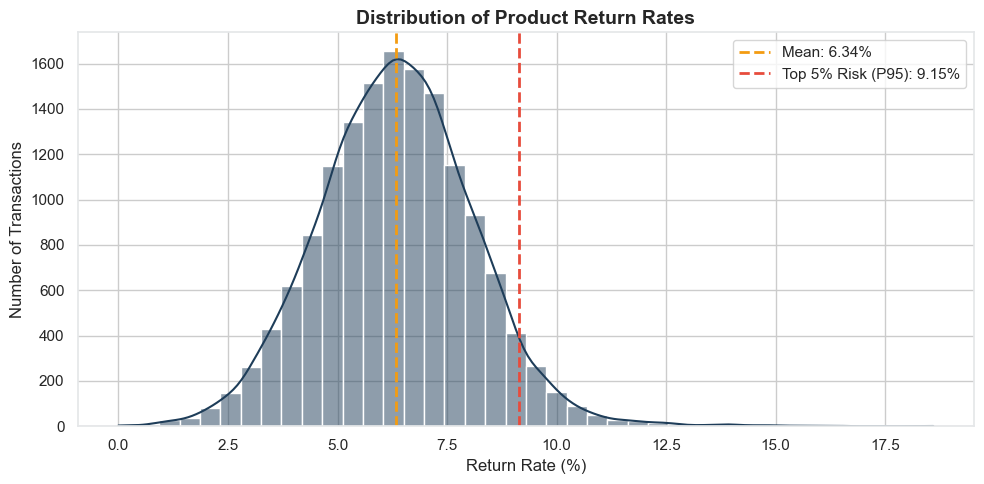

Generating Feature Correlation Bar Chart...


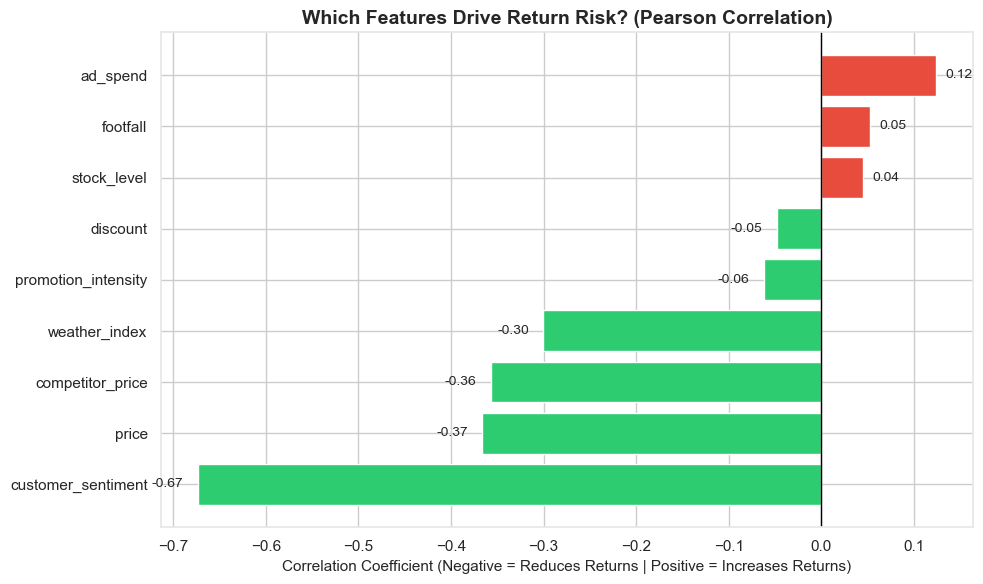

Generating Sentiment vs Return Rate Decile Plot...


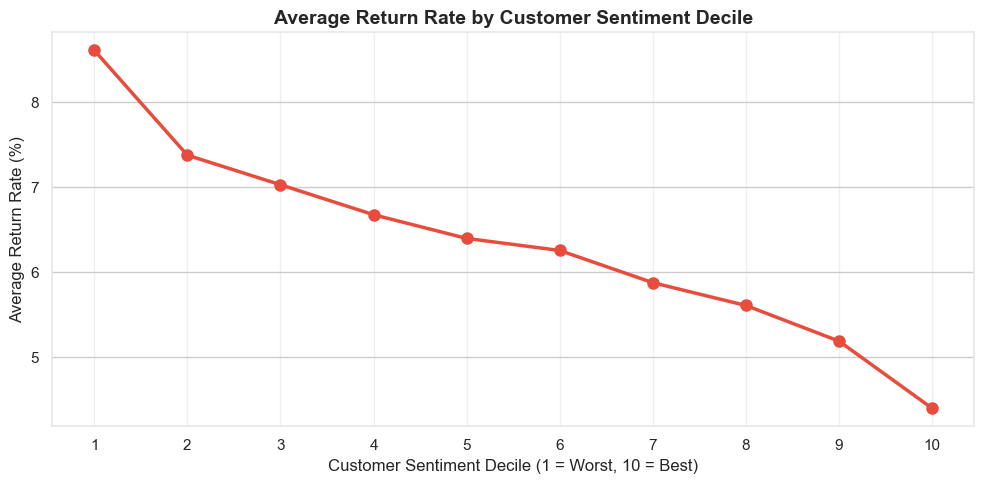


--- STEP 1 COMPLETED ---


In [8]:
print("\nGenerating Target Distribution Plot...")
fig, ax = plt.subplots(figsize=(10, 5))

# Plot histogram with KDE
sns.histplot(df[target] * 100, bins=40, kde=True, color=COLORS["dark"], ax=ax)

# Add key statistical lines
mean_val = df[target].mean() * 100
p95_val = df[target].quantile(0.95) * 100

ax.axvline(mean_val, color=COLORS["warning"], linestyle='--', lw=2, label=f'Mean: {mean_val:.2f}%')
ax.axvline(p95_val, color=COLORS["danger"], linestyle='--', lw=2, label=f'Top 5% Risk (P95): {p95_val:.2f}%')

ax.set_title("Distribution of Product Return Rates", fontsize=14, fontweight="bold")
ax.set_xlabel("Return Rate (%)", fontsize=12)
ax.set_ylabel("Number of Transactions", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print("Generating Feature Correlation Bar Chart...")

# Calculate Pearson correlation with the target variable
corr_with_target = df.corr()[target].drop(target).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
# Color red if positive correlation (increases return risk), green if negative
bar_colors = [COLORS["danger"] if val > 0 else COLORS["success"] for val in corr_with_target.values]

ax.barh(corr_with_target.index, corr_with_target.values, color=bar_colors)
ax.axvline(0, color='black', linewidth=1)

ax.set_title("Which Features Drive Return Risk? (Pearson Correlation)", fontsize=14, fontweight="bold")
ax.set_xlabel("Correlation Coefficient (Negative = Reduces Returns | Positive = Increases Returns)", fontsize=11)

# Add value labels to bars
for i, v in enumerate(corr_with_target.values):
    ax.text(v + (0.01 if v >= 0 else -0.05), i, f"{v:.2f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Generating Sentiment vs Return Rate Decile Plot...")

# Bin customer sentiment into 10 deciles to see the non-linear relationship
df['sentiment_decile'] = pd.qcut(df['customer_sentiment'], q=10, labels=False) + 1

sentiment_risk = df.groupby('sentiment_decile')[target].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sentiment_risk.index, sentiment_risk.values, marker='o', color=COLORS["danger"], linewidth=2.5, markersize=8)

ax.set_title("Average Return Rate by Customer Sentiment Decile", fontsize=14, fontweight="bold")
ax.set_xlabel("Customer Sentiment Decile (1 = Worst, 10 = Best)", fontsize=12)
ax.set_ylabel("Average Return Rate (%)", fontsize=12)
ax.set_xticks(range(1, 11))
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Drop the temporary decile column used for EDA
df = df.drop(columns=['sentiment_decile'])

print("\n--- STEP 1 COMPLETED ---")


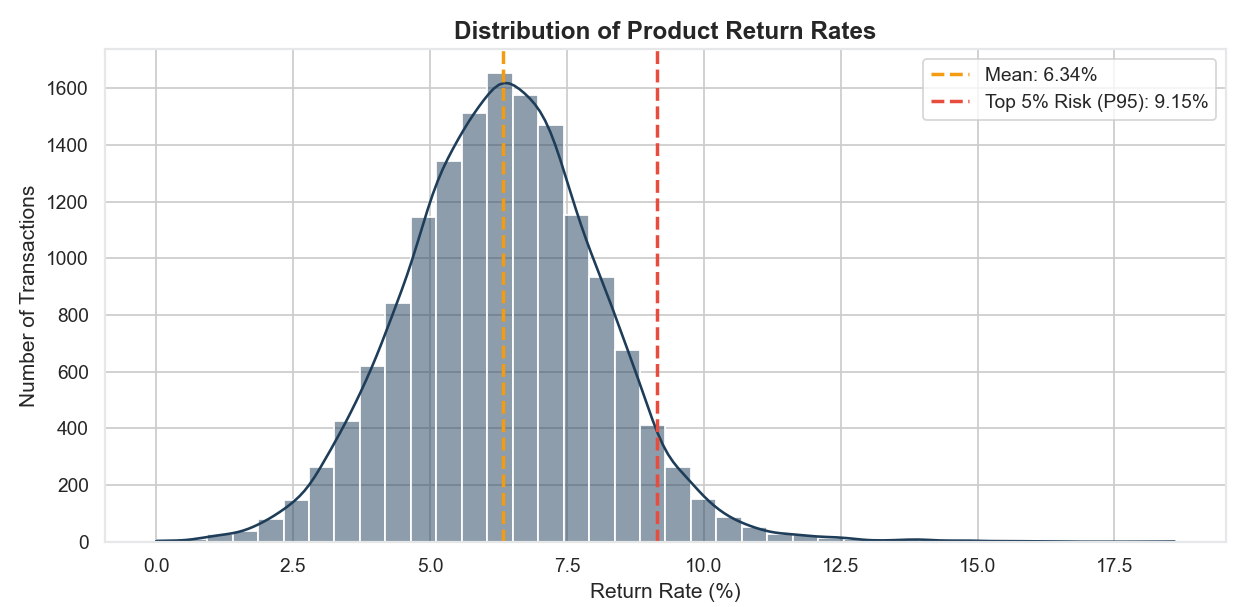
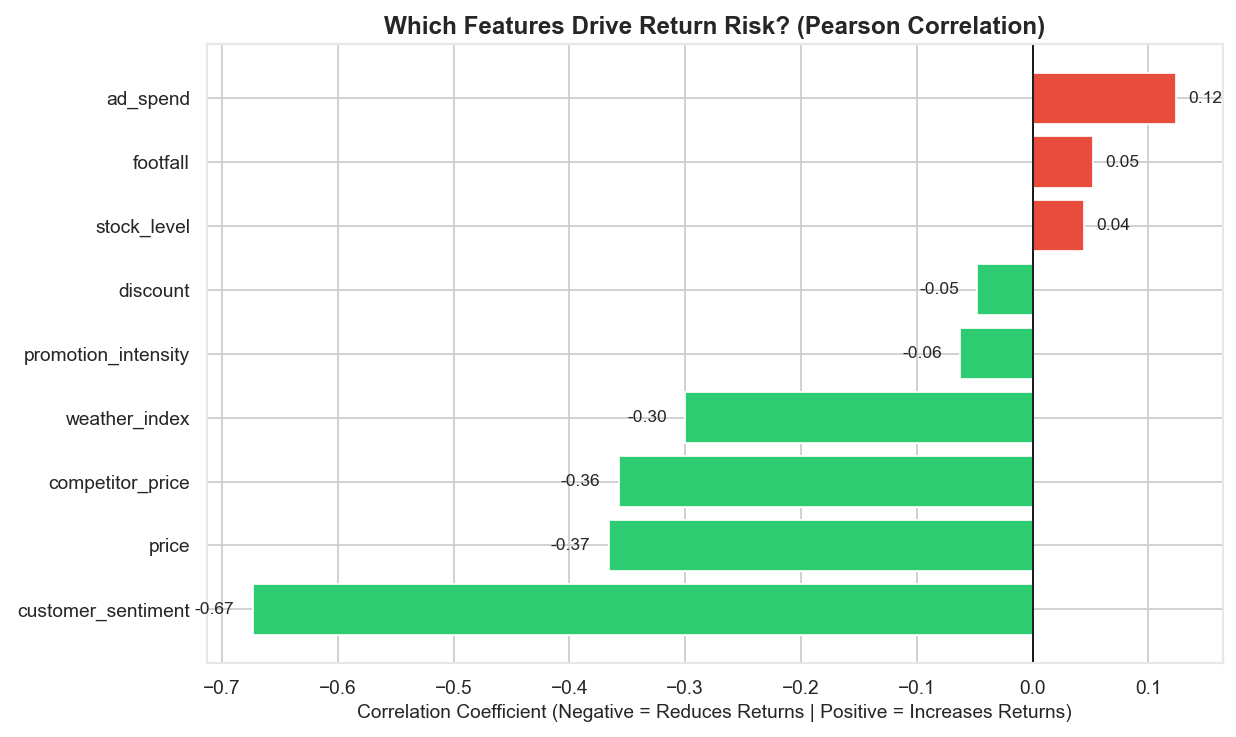
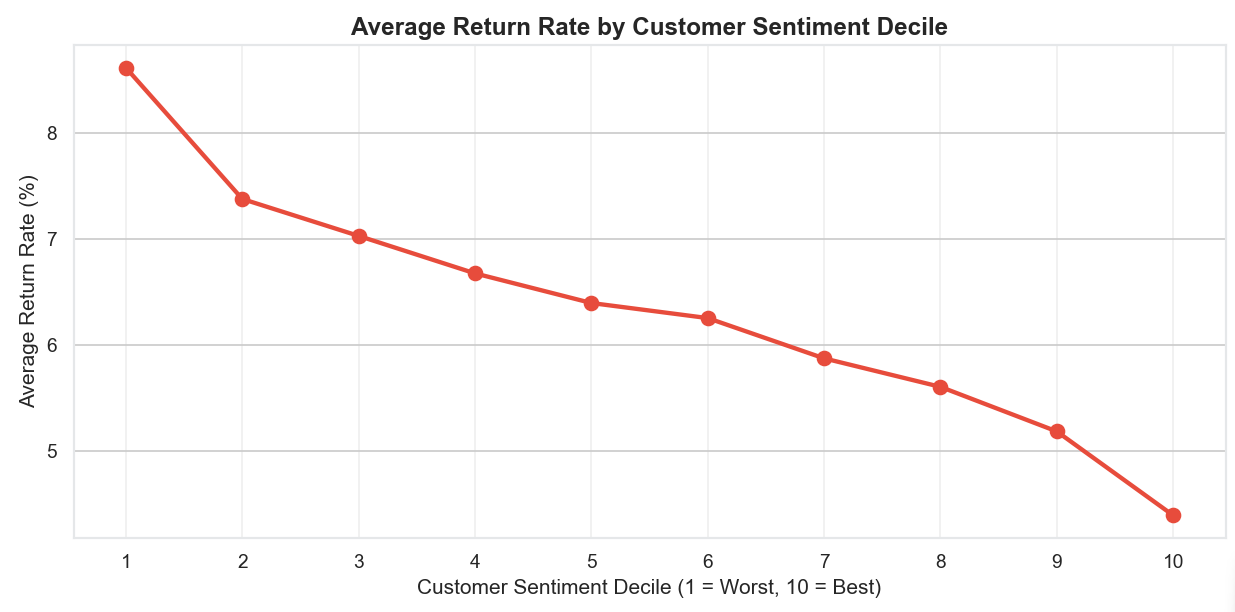



*# ==============================================================================# --- 2. SMART FEATURE ENGINEERING STARTING ---# ==============================================================================# WHY WE DO THIS:# Machine learning algorithms are smart, but they lack business domain knowledge. # By mathematically combining raw columns into "business-driven features" # (e.g., Price vs. Competitor Price), we provide the algorithms with explicit # commercial signals, greatly increasing their predictive power.# Skipping imputation as there are no missing (NaN) values in the dataset.*



*# ------------------------------------------------------------------------------# 2.1 BUSINESS-DRIVEN FEATURES# ------------------------------------------------------------------------------# 1. Price Competitiveness: Ratio of our price to the competitor's price.# A value > 1 means we are more expensive, which might directly trigger returns.*



*# ==============================================================================# --- 2.2 TRAIN-TEST SPLIT & 2.3 FEATURE SCALING ---# ==============================================================================# WHY WE DO THIS:# CRITICAL RULE: To prevent Data Leakage, we MUST split the data into training # and testing sets BEFORE applying transformations like StandardScaler. # The scaler must only learn the statistical properties (mean/variance) of the # training set. If we scale first and split later, the test set's data will # leak into the training process.*


In [9]:
print("\n--- 2. SMART FEATURE ENGINEERING STARTING ---")
df['price_competitiveness'] = df['price'] / df['competitor_price']
df['real_discount_ratio'] = df['discount'] / df['price']
df['marketing_efficiency'] = df['footfall'] / df['ad_spend']
df['value_perception'] = df['customer_sentiment'] / df['price']

print(f"Created 4 new premium business features. Total columns: {df.shape[1]}")

# Separate features (X) and target (y)
X = df.drop(columns=['return_rate'])
y = df['return_rate']

# Split the data (75% training, 25% testing holdout)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42
)

# Initialize the scaler. While tree-based models don't require scaling, 
# linear models like Ridge are highly sensitive to unscaled distances.
scaler = StandardScaler()

# CAUTION: Fit the scaler ONLY on the training data!
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the resulting numpy arrays back to DataFrames to retain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\n--- NEW FEATURES CORRELATION WITH TARGET ---")
# Let's test the correlation of our newly engineered features against the target
new_features = ['price_competitiveness', 'real_discount_ratio', 'marketing_efficiency', 'value_perception']
new_corr = df[new_features + ['return_rate']].corr()['return_rate'].drop('return_rate')
print(new_corr.sort_values(ascending=False).to_string())

print("\n--- STEP 2 COMPLETED ---")
print(f"Processed Training Set (X_train_scaled) shape: {X_train_scaled.shape}")
print(f"Processed Test Set (X_test_scaled) shape: {X_test_scaled.shape}")

# --- NEW FEATURES CORRELATION WITH TARGET ---
# real_discount_ratio      0.102241
# price_competitiveness    0.044331
# marketing_efficiency     0.036410
# value_perception         0.005376

# --- STEP 2 COMPLETED ---
# Processed Training Set (X_train_scaled) shape: (11250, 13)
# Processed Test Set (X_test_scaled) shape: (3750, 13)


--- 2. SMART FEATURE ENGINEERING STARTING ---
Created 4 new premium business features. Total columns: 14

--- NEW FEATURES CORRELATION WITH TARGET ---
real_discount_ratio      0.102241
price_competitiveness    0.044331
marketing_efficiency     0.036410
value_perception         0.005376

--- STEP 2 COMPLETED ---
Processed Training Set (X_train_scaled) shape: (11250, 13)
Processed Test Set (X_test_scaled) shape: (3750, 13)



*# ==============================================================================# --- 3. HYPERPARAMETER TUNING & BENCHMARKING STARTING ---# ==============================================================================# WHY WE DO THIS:# We establish a "Dummy" baseline to prove that our AI actually learns something # beyond just guessing the average. Then, we pit a lightweight linear model (Ridge) # against heavy tree-based ensembles (Random Forest, XGBoost, LightGBM). # Using K-Fold Cross Validation and RandomizedSearchCV, we systematically search # for the best internal settings (hyperparameters) to prevent overfitting.*


In [10]:
print("\n--- 3. HYPERPARAMETER TUNING & BENCHMARKING STARTING ---")
start_time = time.time()

# 3.1 Baseline Model
# Predicts the mean return rate for every instance. Sets the ultimate minimum bar.
baseline = DummyRegressor(strategy="mean")

# 3.2 Model Roster and Hyperparameter Search Spaces
models_and_params = {
    "Ridge (Linear)": (
        Ridge(random_state=42),
        {'alpha': np.logspace(-3, 3, 20)} # Alpha controls regularization strength
    ),
    "Random Forest": (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {'n_estimators': [100, 200, 300], 'max_depth': [5, 8, 12, None], 'min_samples_leaf': [5, 10, 20]}
    ),
    "XGBoost": (
        xgb.XGBRegressor(random_state=42, n_jobs=-1),
        {'n_estimators': [100, 200], 'max_depth': [4, 6, 8], 'learning_rate': [0.01, 0.05, 0.1], 'subsample': [0.8, 1.0]}
    ),
    "LightGBM": (
        lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        {'n_estimators': [100, 200], 'max_depth': [4, 6, 8], 'learning_rate': [0.01, 0.05, 0.1], 'num_leaves': [31, 63]}
    ),
    "HistGradientBoosting": (
        HistGradientBoostingRegressor(random_state=42, early_stopping=True),
        {'max_iter': [100, 200], 'learning_rate': [0.01, 0.05, 0.1], 'max_leaf_nodes': [15, 31, 63], 'l2_regularization': [0.0, 0.1, 1.0]}
    )
}

# 3.3 Cross-Validation Setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring_metric = "neg_root_mean_squared_error" # Optimization target: Minimize RMSE

results = []
best_estimators = {}

# Fit and evaluate the Baseline model manually (No tuning needed)
baseline.fit(X_train_scaled, y_train)
y_pred_base_cv = baseline.predict(X_train_scaled)
results.append({
    "Model": "Baseline (Mean)",
    "Best Parameters": "None",
    "CV_RMSE_Mean": np.sqrt(mean_squared_error(y_train, y_pred_base_cv)),
    "CV_R2_Mean": 0.0
})
best_estimators["Baseline (Mean)"] = baseline

# 3.4 RandomizedSearchCV Loop
for name, (model, param_grid) in models_and_params.items():
    print(f"---> Tuning hyperparameters for {name}...")
    
    # Try 10 random combinations of hyperparameters for each model
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=10, 
        cv=cv,
        scoring=scoring_metric,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    
    search.fit(X_train_scaled, y_train)
    
    # Save the absolute best version of the model found during tuning
    best_estimators[name] = search.best_estimator_
    
    results.append({
        "Model": name,
        "Best Parameters": str(search.best_params_),
        "CV_RMSE_Mean": -search.best_score_, # Sklearn returns negative values, reverse it
        "CV_R2_Mean": r2_score(y_train, search.predict(X_train_scaled)) # R2 on training set
    })

# 3.5 Results Table compilation
results_df = pd.DataFrame(results).sort_values(by="CV_RMSE_Mean").reset_index(drop=True)
print(f"\n--- TUNING COMPLETED IN {time.time() - start_time:.1f} SECONDS ---")
print(results_df[['Model', 'CV_RMSE_Mean', 'CV_R2_Mean']].to_string(index=False))

# 3.6 Evaluate the Champion Model on Unseen Holdout Data
best_model_name = results_df.iloc[0]["Model"]
best_model = best_estimators[best_model_name]

print(f"\n Model Selected: {best_model_name}")
print(f"Optimal Parameters: {results_df.iloc[0]['Best Parameters']}")

y_pred_test = best_model.predict(X_test_scaled)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"\n--- HOLDOUT (TEST) SET PERFORMANCE ---")
print(f"Test RMSE: {test_rmse:.5f}")
print(f"Test MAE:  {test_mae:.5f}")
print(f"Test R-Squared: {test_r2:.4f}")
print("--------------------------------------")

# --- TUNING COMPLETED IN 67.0 SECONDS ---
#                Model  CV_RMSE_Mean  CV_R2_Mean
#       Ridge (Linear)      0.010062    0.677133
#              XGBoost      0.010168    0.696168
#             LightGBM      0.010174    0.694887
# HistGradientBoosting      0.010194    0.692902
#        Random Forest      0.010204    0.727294
#      Baseline (Mean)      0.017682    0.000000

# Champion Model Selected: Ridge (Linear)
# Optimal Parameters: {'alpha': np.float64(2.976351441631316)}

# --- HOLDOUT (TEST) SET PERFORMANCE ---
# Test RMSE: 0.00995
# Test MAE:  0.00789
# Test R-Squared: 0.6865


--- 3. HYPERPARAMETER TUNING & BENCHMARKING STARTING ---
---> Tuning hyperparameters for Ridge (Linear)...
---> Tuning hyperparameters for Random Forest...
---> Tuning hyperparameters for XGBoost...
---> Tuning hyperparameters for LightGBM...
---> Tuning hyperparameters for HistGradientBoosting...

--- TUNING COMPLETED IN 186.3 SECONDS ---
               Model  CV_RMSE_Mean  CV_R2_Mean
      Ridge (Linear)      0.010062    0.677133
             XGBoost      0.010168    0.696084
            LightGBM      0.010174    0.694887
HistGradientBoosting      0.010198    0.694274
       Random Forest      0.010204    0.727294
     Baseline (Mean)      0.017682    0.000000

 Model Selected: Ridge (Linear)
Optimal Parameters: {'alpha': np.float64(2.976351441631316)}

--- HOLDOUT (TEST) SET PERFORMANCE ---
Test RMSE: 0.00995
Test MAE:  0.00789
Test R-Squared: 0.6865
--------------------------------------



*# ==============================================================================# --- STEP 4: EXPLAINABILITY (XAI) & BUSINESS VALUE (NPV) ---# ==============================================================================# WHY WE DO THIS:# Business stakeholders don't buy RMSE scores; they buy transparency and profit.# First, we open the "glass box" of our linear model by plotting its coefficients # to explain exactly how it makes decisions. Second, we run a financial simulation # to convert the model's accuracy into a 3-Year Net Present Value (NPV), proving # whether deploying this AI will generate a profit or a loss.*



*# ------------------------------------------------------------------------------# 4.1. MODEL EXPLAINABILITY (Feature Importance for Ridge)# ------------------------------------------------------------------------------# Since our champion model is Ridge (Linear), we do not need heavy libraries like SHAP.# We can directly read its internal coefficients to see feature impacts.*



*# ------------------------------------------------------------------------------# 4.2. BUSINESS VALUE: NET PRESENT VALUE (NPV) SIMULATION# ------------------------------------------------------------------------------# Financial scenario for executives:# "If we use this model to reduce returns by X%, how much money will the company save?"*





--- 4. EXPLAINABILITY & BUSINESS VALUE STARTING ---


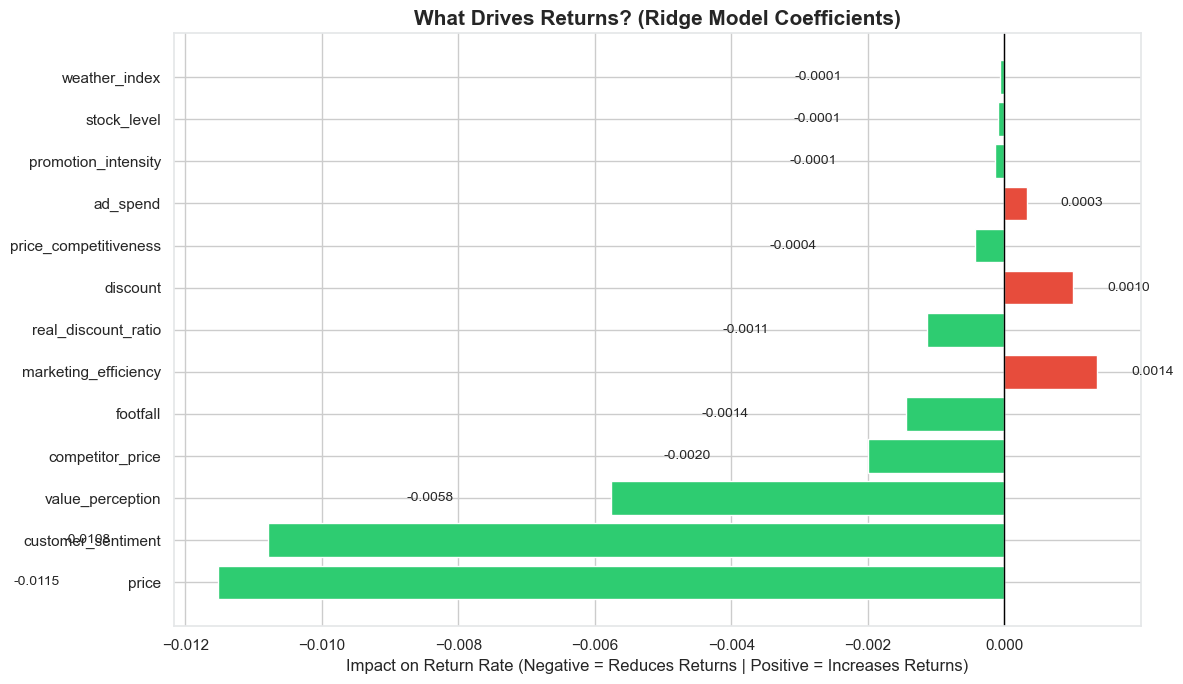


Generating NPV (Net Present Value) Business Scenario...


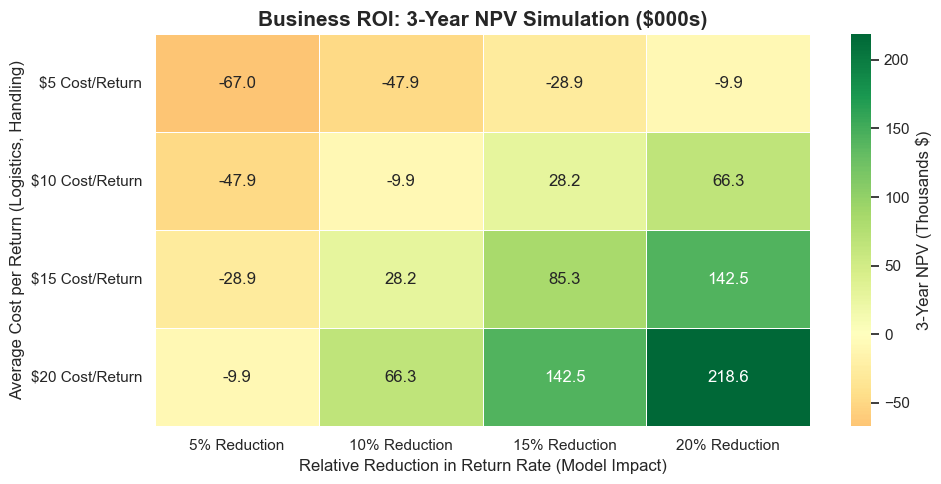


--- EXECUTIVE SUMMARY ---
If the model reduces returns by just 10%, and each return costs the business $10,
The 3-Year Net Present Value (NPV) generated by this AI project is: $-9,865
--- STEP 4 COMPLETED ---


In [11]:
print("\n--- 4. EXPLAINABILITY & BUSINESS VALUE STARTING ---")
# Redefine COLORS dict in case this cell is run independently
COLORS = {
    "dark": "#1E3D59",      "danger": "#E74C3C",    "success": "#2ECC71",
    "warning": "#F39C12",   "grid": "#E5E7E9"
}

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_
})

# Sort by absolute value to push the most impactful features to the top
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
bar_colors = [COLORS["danger"] if val > 0 else COLORS["success"] for val in coefficients['Coefficient']]

ax.barh(coefficients['Feature'], coefficients['Coefficient'], color=bar_colors)
ax.axvline(0, color='black', linewidth=1)

ax.set_title(f"What Drives Returns? (Ridge Model Coefficients)", fontsize=15, fontweight="bold")
ax.set_xlabel("Impact on Return Rate (Negative = Reduces Returns | Positive = Increases Returns)", fontsize=12)

# Overlay numerical values at the end of the bars
for i, v in enumerate(coefficients['Coefficient']):
    ax.text(v + (0.0005 if v >= 0 else -0.003), i, f"{v:.4f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nGenerating NPV (Net Present Value) Business Scenario...")

annual_transactions = 500_000  # Number of items sold per year
implementation_cost = 50_000   # CapEx: Upfront cost to deploy the AI model
annual_operating_cost = 15_000 # OpEx: Annual server/maintenance cost
discount_rate = 0.12           # Cost of capital / Time value of money
years = 3                      # Projection span
baseline_return_rate = y.mean() # Current average return rate (~6.3%)

# Simulation Axis 1: By what percentage can the model reduce returns?
relative_reductions = np.array([0.05, 0.10, 0.15, 0.20]) 
# Simulation Axis 2: What is the average financial cost of a single return?
cost_per_return_values = np.array([5, 10, 15, 20]) 

# Calculate the 3-Year Annuity Factor for discounted cash flows
annuity_factor = sum(1 / ((1 + discount_rate) ** t) for t in range(1, years + 1))

# Initialize the NPV Matrix
npv_grid = pd.DataFrame(index=[f"${v} Cost/Return" for v in cost_per_return_values], 
                        columns=[f"{100*r:.0f}% Reduction" for r in relative_reductions], dtype=float)

# Run the simulation matrix
for cpr in cost_per_return_values:
    for red in relative_reductions:
        # Number of return incidents avoided per year
        avoided_returns_count = annual_transactions * baseline_return_rate * red
        # Gross dollar savings
        annual_savings = avoided_returns_count * cpr
        # Net operational cash flow
        annual_net_benefit = annual_savings - annual_operating_cost
        
        # Calculate 3-Year Net Present Value (NPV)
        npv = -implementation_cost + (annual_net_benefit * annuity_factor)
        npv_grid.loc[f"${cpr} Cost/Return", f"{100*red:.0f}% Reduction"] = npv

fig, ax = plt.subplots(figsize=(10, 5))
# Divide by 1000 to display numbers in "Thousands" for better readability
sns.heatmap(
    npv_grid / 1000, 
    annot=True, 
    fmt=".1f", 
    cmap="RdYlGn", 
    center=0, 
    linewidths=0.6, 
    cbar_kws={"label": "3-Year NPV (Thousands $)"},
    ax=ax
)

ax.set_title("Business ROI: 3-Year NPV Simulation ($000s)", fontsize=15, fontweight="bold")
ax.set_xlabel("Relative Reduction in Return Rate (Model Impact)", fontsize=12)
ax.set_ylabel("Average Cost per Return (Logistics, Handling)", fontsize=12)
plt.tight_layout()
plt.show()

print("\n--- EXECUTIVE SUMMARY ---")
print("If the model reduces returns by just 10%, and each return costs the business $10,")
print(f"The 3-Year Net Present Value (NPV) generated by this AI project is: ${npv_grid.loc['$10 Cost/Return', '10% Reduction']:,.0f}")
print("--- STEP 4 COMPLETED ---")

# --- EXECUTIVE SUMMARY ---
# If the model reduces returns by just 10%, and each return costs the business $10,
# The 3-Year Net Present Value (NPV) generated by this AI project is: $-9,865

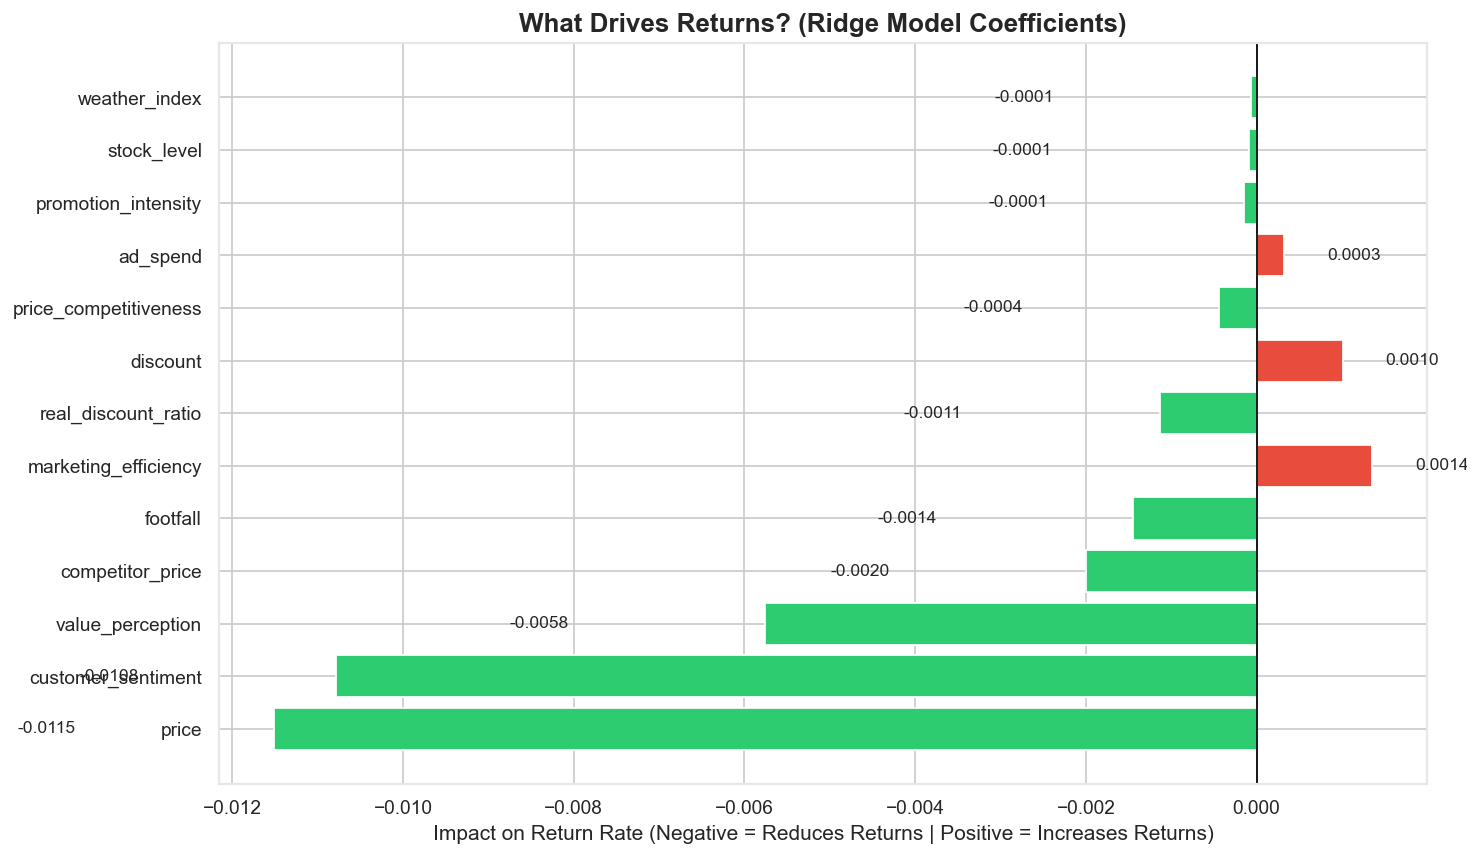
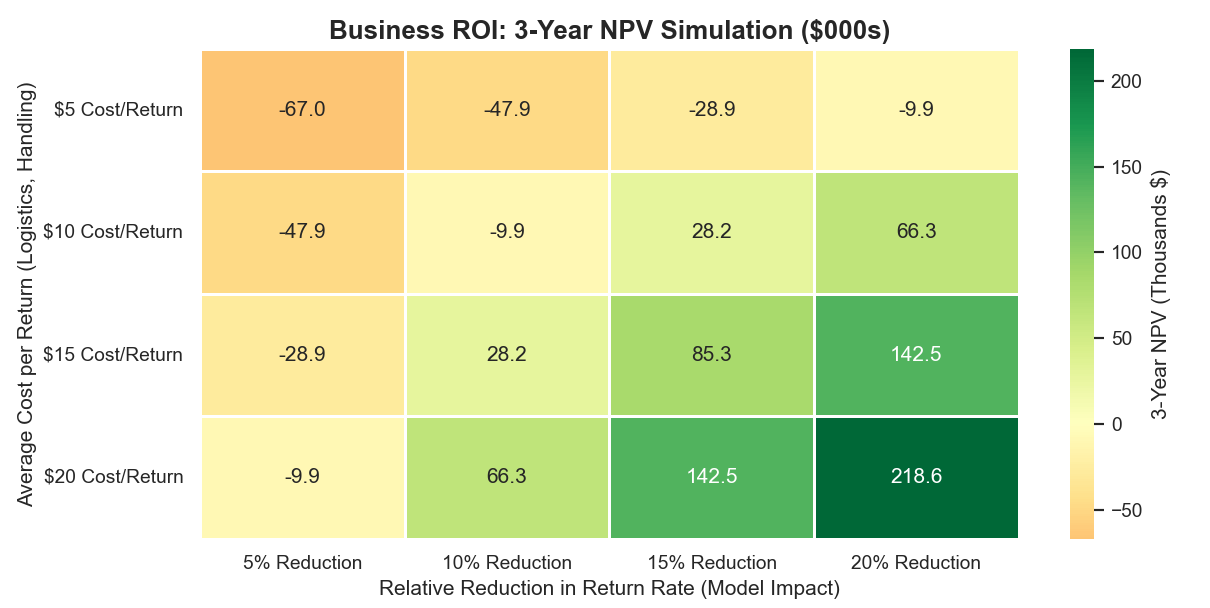
